In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

data = pd.read_csv("Spotify_Tracks_Dataset_Clean.csv")
df = data.copy()

In [2]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

In [3]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


---

In [4]:
loudness = df["loudness"]

In [5]:
mean_loudness = loudness.mean()
median_loudness = loudness.median()
mode_loudness = loudness.mode()[0]

print("Mean loudness:", mean_loudness)
print("Median loudness:", median_loudness)
print("Mode loudness:", mode_loudness)  

Mean loudness: -8.243407991263684
Median loudness: -6.997
Mode loudness: -5.662


In [6]:
var_loudness = loudness.var()
std_dev_loudness = loudness.std()

min_loudness = loudness.min()
max_loudness = loudness.max()
range_loudness = max_loudness - min_loudness

Q1 = loudness.quantile(0.25)
Q3 = loudness.quantile(0.75)
iqr_loudness = Q3 - Q1


print("Variance loudness:", var_loudness)
print("Standard deviation loudness:", std_dev_loudness)
print("Minimum loudness:", min_loudness)
print("Maximum loudness:", max_loudness)
print("Loudness range:", range_loudness)
print("Interquartile loudness range:", iqr_loudness)

Variance loudness: 25.11434610719686
Standard deviation loudness: 5.01142156550383
Minimum loudness: -49.531
Maximum loudness: 4.532
Loudness range: 54.063
Interquartile loudness range: 4.996999999999999


---

In [7]:
song_loud = df[(df["track_name"] == "Tornado Of Souls - Remastered 2004") & (df["artists"] == "Megadeth")]["loudness"].values[0]
song_soft = df[(df["track_name"] == "Ceiling Fan Sound on Low Power") & (df["artists"] == "Atmosphere Asmr")]["loudness"].values[0]
song_dist = df[(df["track_name"] == "Time Bomb") & (df["artists"] == "The Red Pears")]["loudness"].values[0]

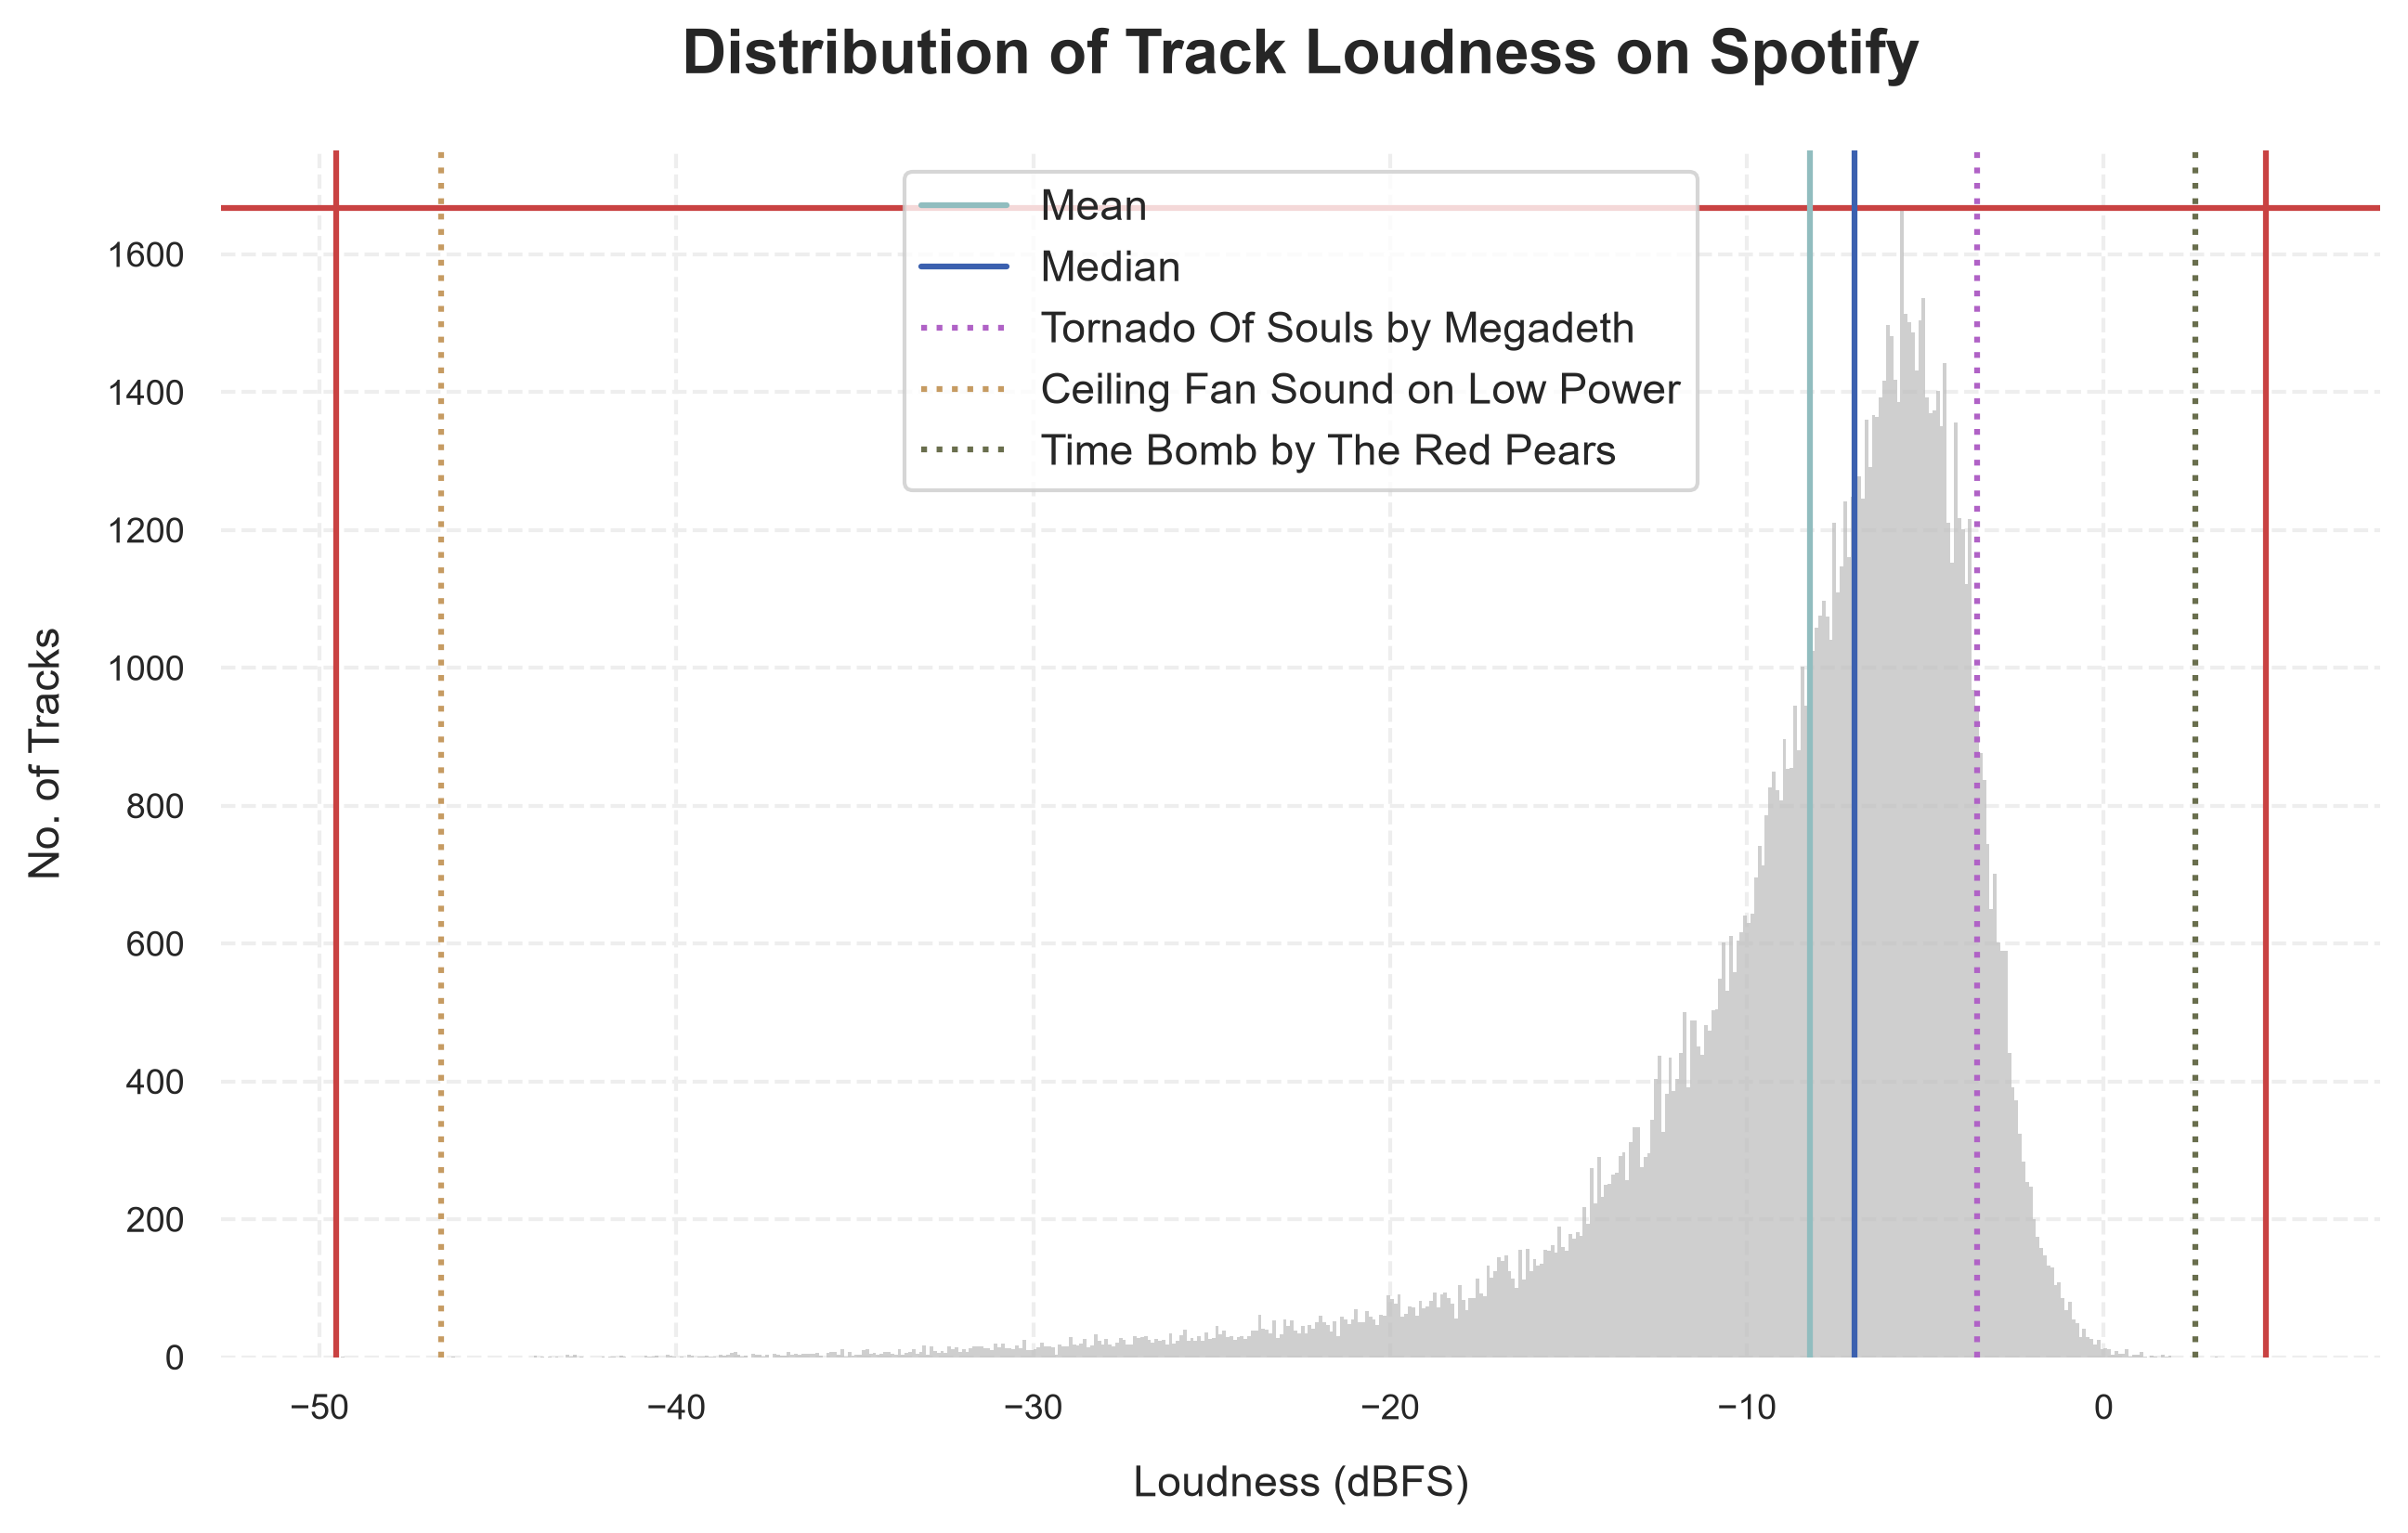

In [8]:
sns.set_theme( style = "whitegrid", font = "arial")
plt.figure(figsize= (10, 5.625), dpi = 300)

loudness_plot = sns.histplot(
    data = df,
    x = "loudness",

    binrange = (-50, 5),
    binwidth = .1,

    color = "#BFBFBF",
    edgecolor = "#00000000"
)


plt.axvline(max_loudness, color = "#C94242")
plt.axvline(min_loudness, color = "#C94242")

max_no_songs_loudness = max([p.get_height() for p in loudness_plot.patches])
plt.axhline(max_no_songs_loudness, color="#C94242")

plt.axvline(mean_loudness, label = f"Mean", color = "#91BDBF")
plt.axvline(median_loudness, label = f"Median", color = "#3B60AF")

plt.axvline(song_loud, label = "Tornado Of Souls by Megadeth", color = "#B062C6", linestyle = ":")
plt.axvline(song_soft, label = "Ceiling Fan Sound on Low Power", color = "#C69B62", linestyle = ":")
plt.axvline(song_dist, label = "Time Bomb by The Red Pears", color = "#696E4D", linestyle = ":")

plt.title("Distribution of Track Loudness on Spotify", fontsize = 16, fontweight = "bold", pad = 20 )
plt.legend(loc = "upper center", fontsize = 11)
plt.xlabel("Loudness (dBFS)", fontsize = 11, labelpad = 10)
plt.ylabel("No. of Tracks", fontsize = 11, labelpad = 10)
plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)

sns.despine(left = True, bottom = True)
plt.grid(color = "#EEEEEE", linestyle = "--", linewidth = 1, zorder = 0)

plt.savefig("Distribution_of_Track_Loudness_on_Spotify.png", bbox_inches="tight")
plt.show()

---

In [9]:
genre_median = df.groupby("track_genre")[["loudness", "tempo"]].median()

genre_quietest = genre_median.nsmallest(3, "loudness").index
genre_slowest = genre_median.nsmallest(3, "tempo").index
genre_quiet_slow = genre_median.loc[genre_quietest.union(genre_slowest)]

genre_loudest = genre_median.nlargest(3, "loudness").index
genre_fastest = genre_median.nlargest(3, "tempo").index
genre_loud_fast = genre_median.loc[genre_loudest.union(genre_fastest)]



In [10]:
#Custom colors for genres
genre_color = []

for genre in genre_median.index:
    if genre in genre_quiet_slow.index:
        genre_color.append("#C69B62")
    elif genre in genre_loud_fast.index:
        genre_color.append("#B062C6")
    else:
        genre_color.append("#3B60AF")

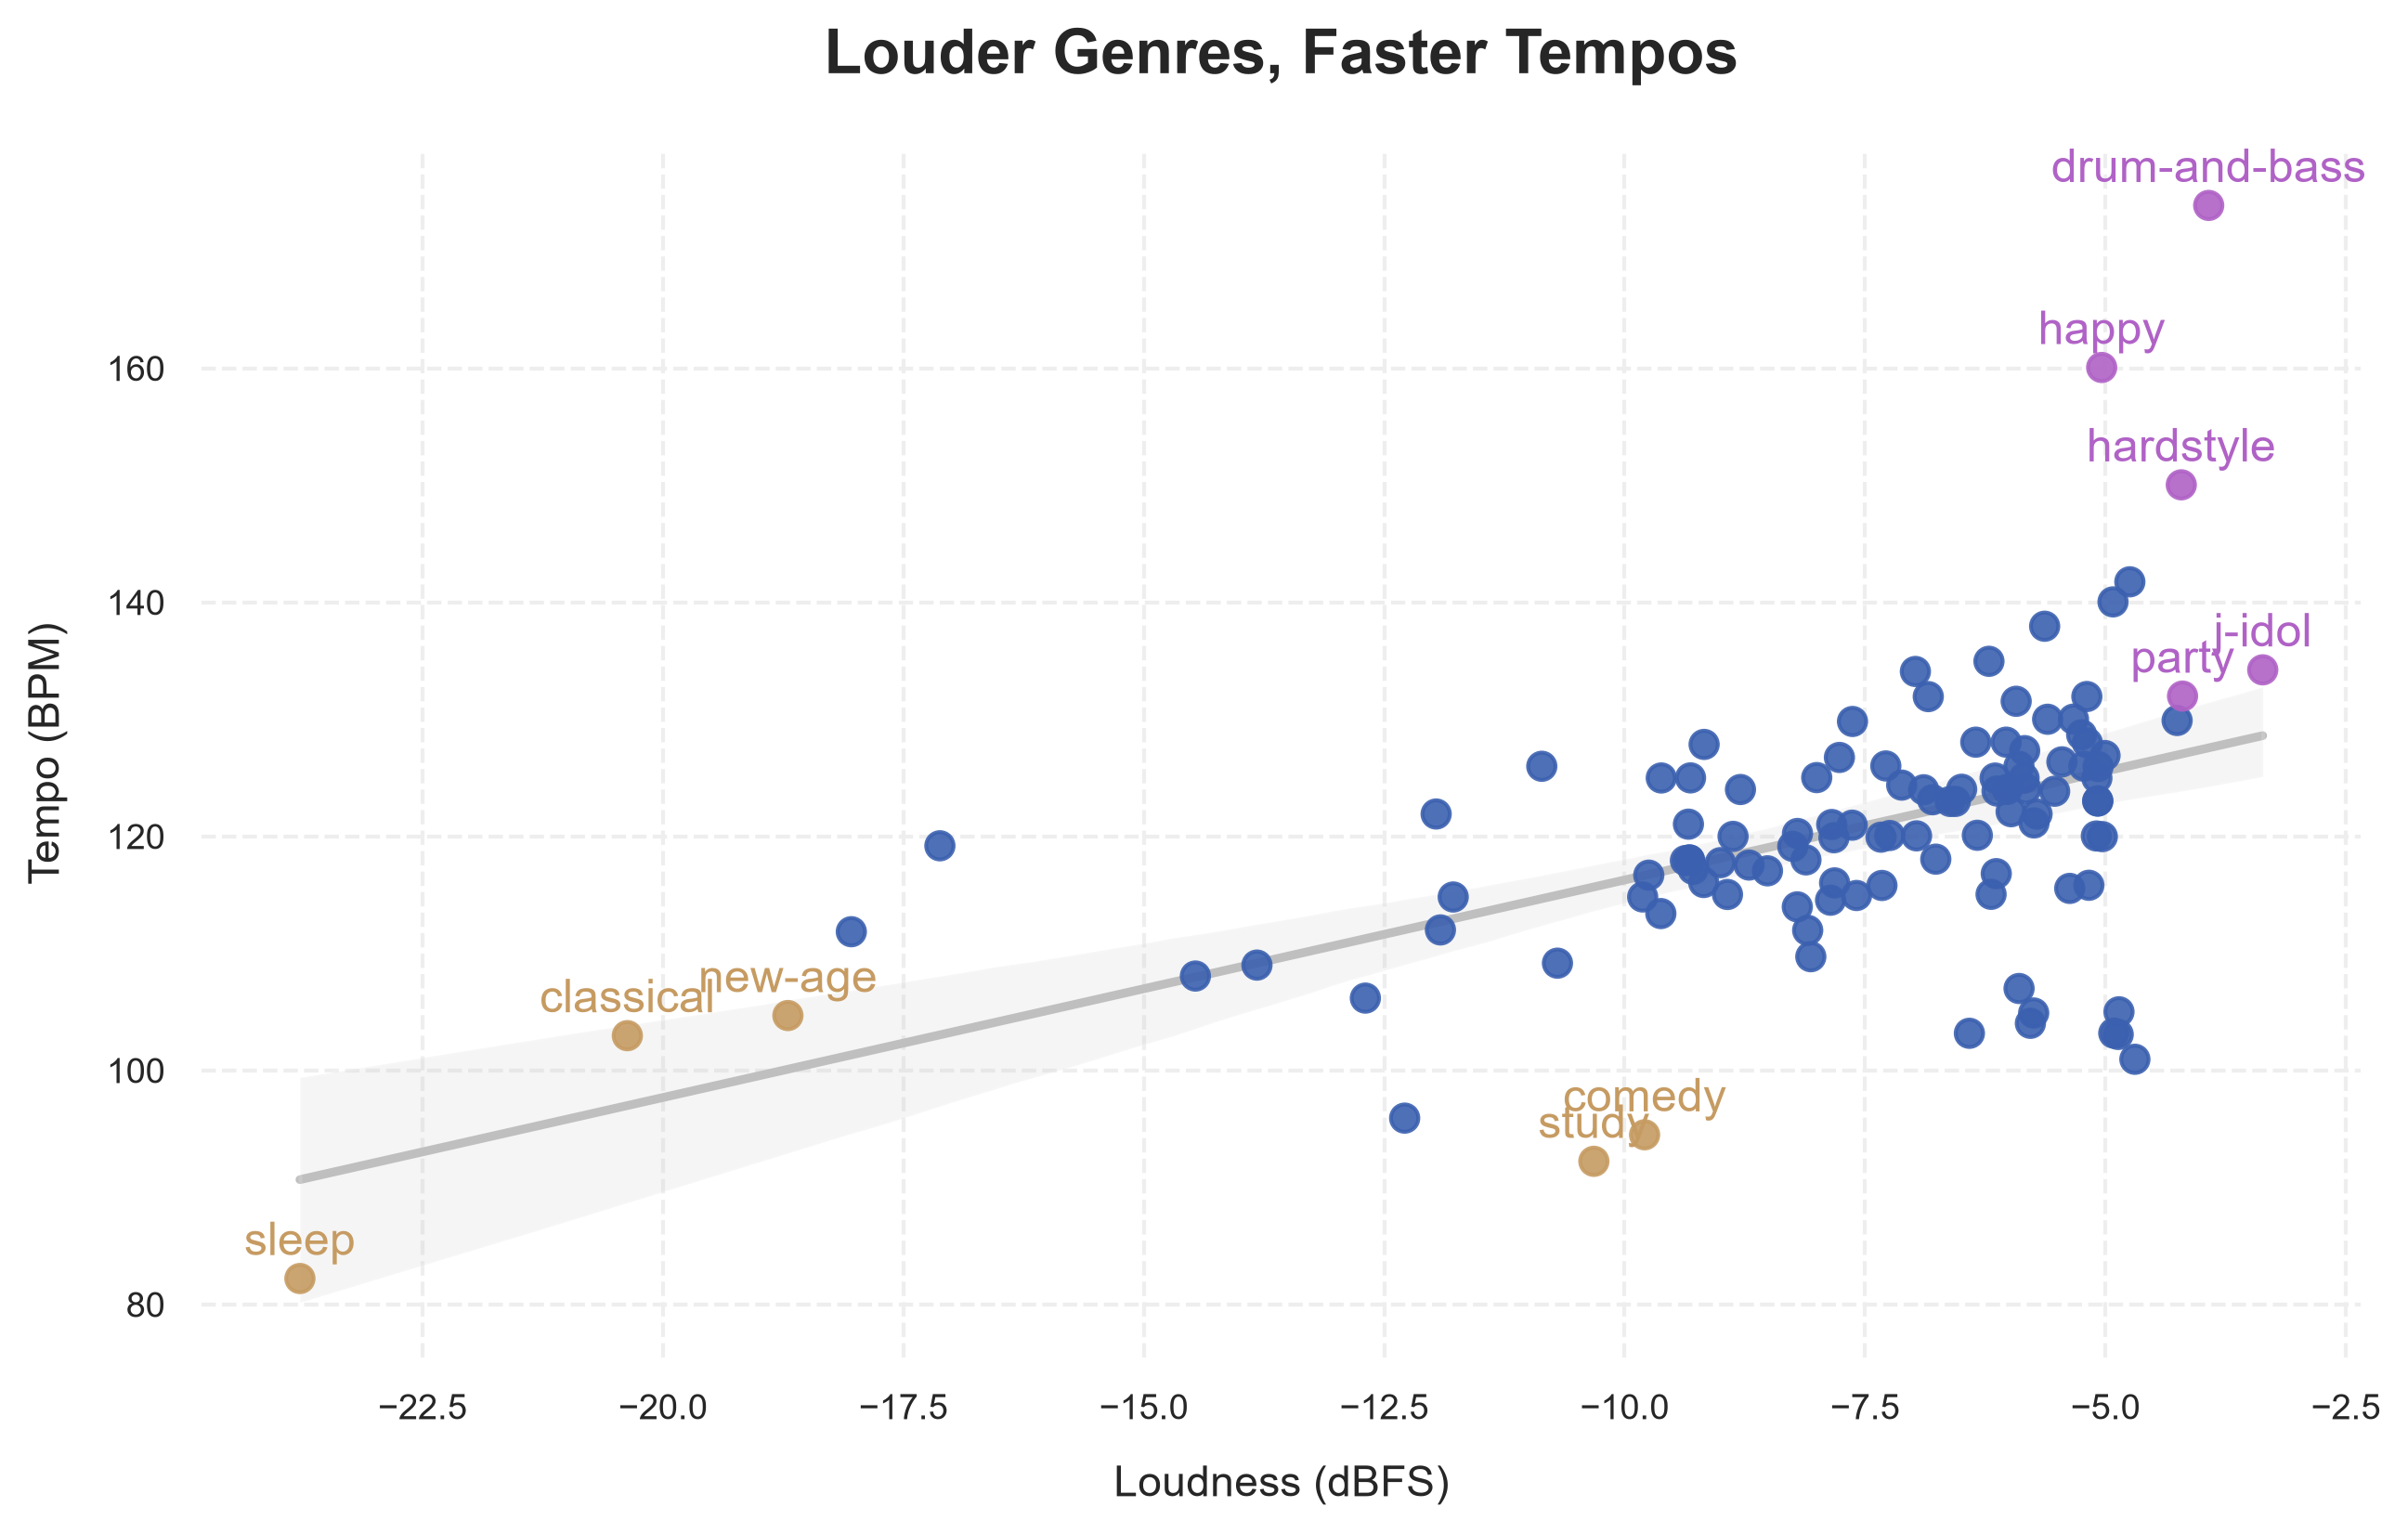

In [11]:
sns.set_theme(style = "whitegrid",font = "arial")
plt.figure(figsize= (10, 5.625), dpi = 300)

sns.regplot(
    data= genre_median, 
    y ="tempo", 
    x ="loudness",

    line_kws = {"color": "#BFBFBF", "zorder": 1},
    scatter_kws={"color": genre_color, "s": 50, "alpha": .9, "zorder": 2}
)

for genre, row in genre_quiet_slow.iterrows():
    plt.text(
        x = row["loudness"], 
        y = row["tempo"] + 2,
        s = genre,
        color = "#C69B62",
        ha = "center"
    )

for genre, row in genre_loud_fast.iterrows():
    plt.text(
        x = row["loudness"], 
        y = row["tempo"] + 2,
        s = genre,
        color = "#B062C6",
        ha = "center"
    )

plt.title("Louder Genres, Faster Tempos", fontsize = 16, fontweight = "bold", pad = 20 )
plt.xlabel("Loudness (dBFS)", fontsize = 11, labelpad = 10)
plt.ylabel("Tempo (BPM)", fontsize = 11, labelpad = 10)
plt.xticks(fontsize = 9)
plt.yticks(fontsize = 9)

sns.despine(left = True, bottom = True)
plt.grid(color = "#EEEEEE", linestyle = "--", linewidth = 1, zorder = 0)

plt.savefig("Louder_Genres_Faster_Tempos.png", bbox_inches="tight")
plt.show()